In [1]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import (
    adfuller,
    ARIMA,
    seasonal_decompose
)


from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt


from src.data.data_ingestion import fetch_data


import warnings
warnings.filterwarnings(action="ignore")

# series ID
series_id = "FEDFUNDS"


df = fetch_data(series_id)
df.head(10)

,FEDFUNDS,Date
0,0.80,1954-07-01
1,1.22,1954-08-01
2,1.07,1954-09-01
3,0.85,1954-10-01
4,0.83,1954-11-01
5,1.28,1954-12-01
6,1.39,1955-01-01
7,1.29,1955-02-01
8,1.35,1955-03-01
9,1.43,1955-04-01


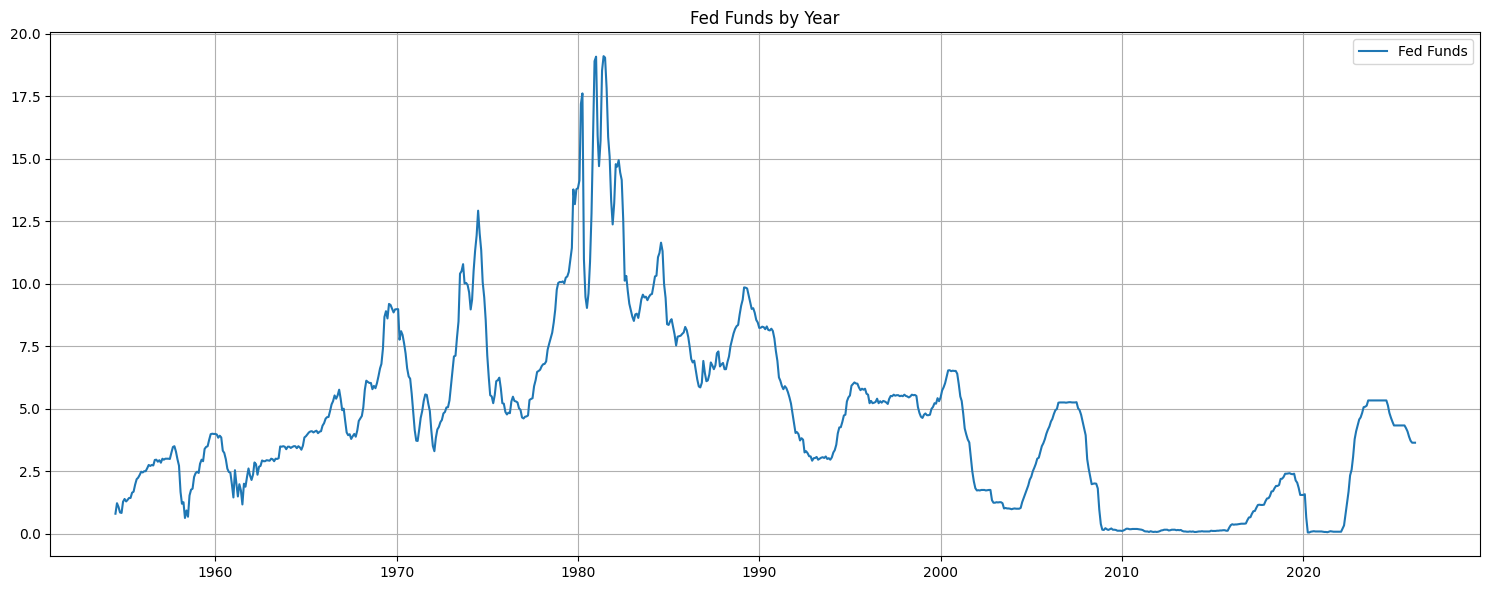

In [2]:
# set Date to datetime and set index to date
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

plt.figure(figsize=(15 ,6))
plt.plot(df,label="Fed Funds")
plt.title("Fed Funds by Year")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()


In [3]:
# p-value for FEDFUNDS using adfuller
adfuller(x=df['FEDFUNDS'])[1]

np.float64(0.035014215687362245)

In [4]:
# first order differencing

df_diff = df['FEDFUNDS'].diff().dropna()
adfuller(df_diff)[1]



np.float64(1.2349737387668314e-08)

In [5]:
# second-order differencing
df_diff_diff = df.diff().diff().dropna()
adfuller(df_diff_diff)[1]

np.float64(4.900022898807741e-27)

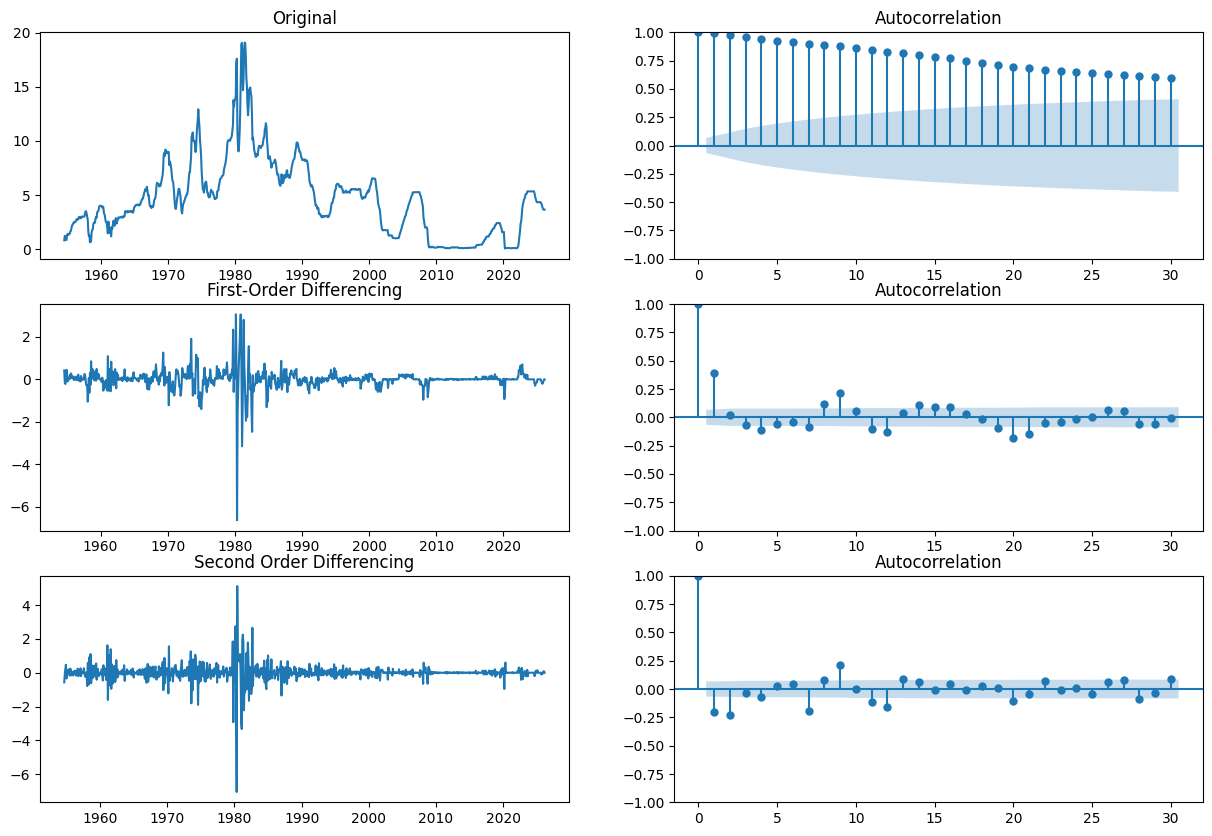

In [6]:
# acf and pacf

plt.rcParams.update({'figure.figsize':(15,10)})
fig, axs = plt.subplots(3,2)
axs[0,0].plot(df[series_id]); axs[0,0].set_title("Original")
plot_acf(df,ax=axs[0,1])


axs[1,0].plot(df[series_id].diff().dropna()); axs[1,0].set_title("First-Order Differencing")
plot_acf(df[series_id].diff().dropna(),ax=axs[1,1])
axs[2,0].plot(df[series_id].diff().diff().dropna()); axs[2,0].set_title("Second Order Differencing")
plot_acf(df[series_id].diff().diff().dropna(),ax=axs[2,1])
plt.show()

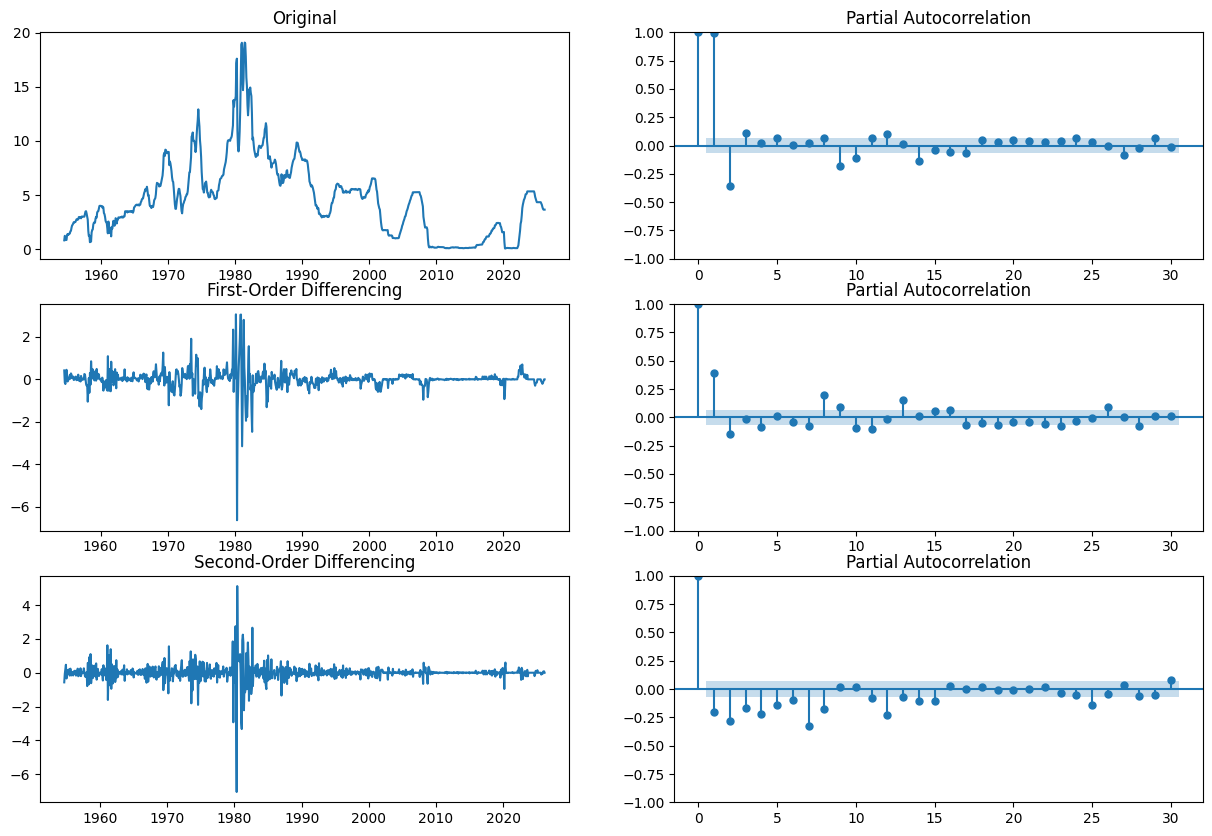

In [7]:
# pacf

fig,axs = plt.subplots(3, 2, figsize=(15, 10))
axs[0,0].plot(df[series_id]);axs[0,0].set_title("Original")
plot_pacf(df[series_id],ax=axs[0,1])

# first-order differencing
axs[1,0].plot(df[series_id].diff().dropna()); axs[1,0].set_title("First-Order Differencing")
plot_pacf(df['FEDFUNDS'].diff().dropna(),ax=axs[1,1])


# Second-Order Differencing
axs[2,0].plot(df[series_id].diff().diff().dropna()); axs[2,0].set_title("Second-Order Differencing")
plot_pacf(df[series_id].diff().diff().dropna(),ax=axs[2,1])
plt.show()

In [8]:
# order=(1,0,0)

model = ARIMA(df[series_id],order=(1,0,0))
model_fitted = model.fit()
model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               FEDFUNDS   No. Observations:                  861
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -589.466
Date:                Fri, 10 Apr 2026   AIC                           1184.932
Time:                        06:37:40   BIC                           1199.206
Sample:                    07-01-1954   HQIC                          1190.396
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1410      2.407      1.720      0.085      -0.577       8.859
ar.L1          0.9904      0.003    344.249      0.000       0.985       0.996
sigma2         0.2292      0.002     93.499      0.000       0.224       0.234
===================================================================================
Ljung-Box (L1) (Q):                 130.83   Jarque-Bera (JB):             91915.72
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.19   Skew:                            -1.98
Prob(H) (two-sided):                  0.00   Kurtosis:                        53.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

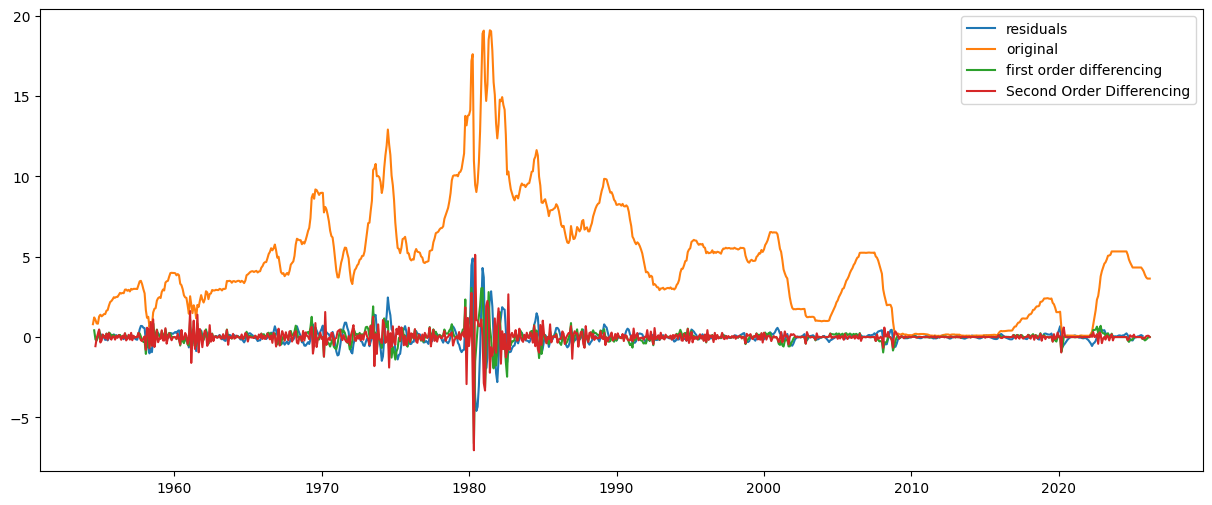

In [9]:
# seasonal decomposition

decompose = seasonal_decompose(x=df,period=12)


plt.figure(figsize=(15, 6))
plt.plot(decompose.resid,label="residuals")
plt.plot(df, label="original")
plt.plot(df_diff,label="first order differencing")
plt.plot(df_diff_diff, label="Second Order Differencing")
plt.legend()
plt.show()

In [10]:
# order (1, 1, 1)
model = ARIMA(df[series_id],order=(1, 1, 1))
model_fitted = model.fit()
model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               FEDFUNDS   No. Observations:                  861
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -509.703
Date:                Fri, 10 Apr 2026   AIC                           1025.405
Time:                        06:37:46   BIC                           1039.676
Sample:                    07-01-1954   HQIC                          1030.869
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1039      0.034      3.023      0.003       0.037       0.171
ma.L1          0.3438      0.035      9.718      0.000       0.274       0.413
sigma2         0.1915      0.003     64.846      0.000       0.186       0.197
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            128793.73
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.14   Skew:                            -3.18
Prob(H) (two-sided):                  0.00   Kurtosis:                        62.61
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

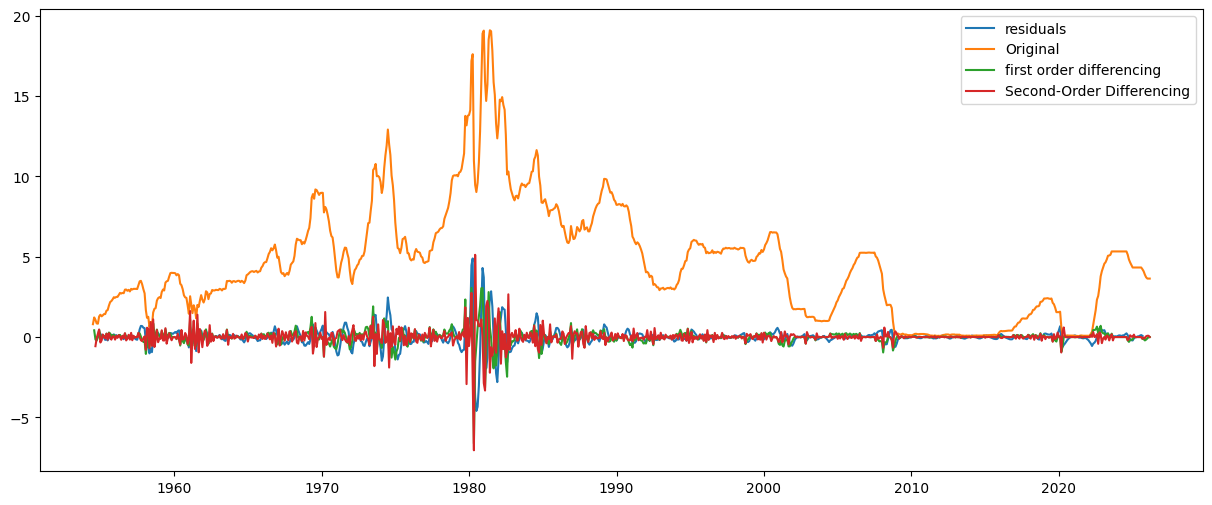

In [11]:
# seasonal Decomposition (order = (1, 1, 1))
decompose = seasonal_decompose(x=df[series_id],period=12)


plt.figure(figsize=(15, 6))
plt.plot(decompose.resid,label="residuals")
plt.plot(df['FEDFUNDS'], label="Original")
plt.plot(df_diff, label="first order differencing")
plt.plot(df_diff_diff, label="Second-Order Differencing")
plt.legend()
plt.show()

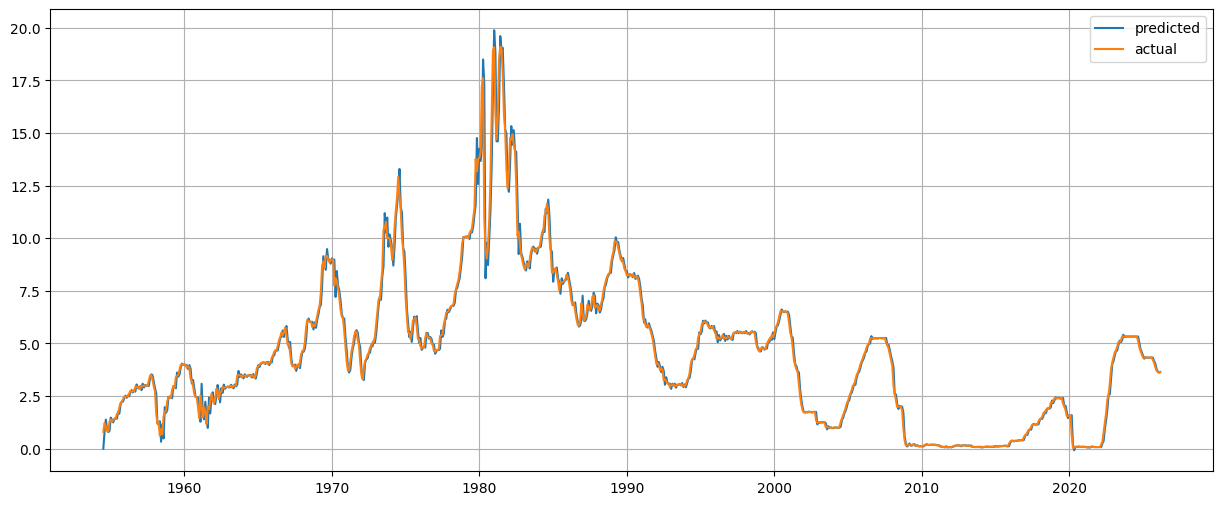

In [12]:
# predicted values
df['predicted'] = model_fitted.fittedvalues

# forecast with 60 steps
forecast = model_fitted.forecast(steps=12)


plt.figure(figsize=(15, 6))
plt.plot(df['predicted'],label="predicted")
plt.plot(df[series_id],label="actual")
plt.legend()
plt.grid()
plt.show()

In [13]:
# metrics

# r2 score
r2 = r2_score(df[series_id], df['predicted'])
print(f"R2 score: {r2*100:.2f}")


# mean absolute error
mae = mean_absolute_error(df[series_id],df['predicted'])
print(f"Mean Absolute Value: {mae:.4}")


# mean absolute percentage error
mape = mean_absolute_percentage_error(df[series_id], df['predicted'])
print(f"Mean Absolute Percentage Error: {mape:.4f}")


# root mean squared error
rmse = np.sqrt(mean_squared_error(df[series_id], df['predicted']))
print(f"Root Mean-Squared Error: {rmse:.4f}")

R2 score: 98.46
Mean Absolute Value: 0.2091
Mean Absolute Percentage Error: 0.0720
Root Mean-Squared Error: 0.4383


In [14]:
print(f"Predicted: {df.head(20)}")
print(f"Actual values: {df.tail(20)}")

Predicted:             FEDFUNDS  predicted
Date                           
1954-07-01      0.80   0.000000
1954-08-01      1.22   0.800000
1954-09-01      1.07   1.383702
1954-10-01      0.85   0.948667
1954-11-01      0.83   0.793304
1954-12-01      1.28   0.840537
1955-01-01      1.39   1.477834
1955-02-01      1.29   1.371225
1955-03-01      1.35   1.251686
1955-04-01      1.43   1.390035
1955-05-01      1.43   1.452050
1955-06-01      1.64   1.422418
1955-07-01      1.68   1.736622
1955-08-01      1.96   1.664686
1955-09-01      2.18   2.090620
1955-10-01      2.24   2.233582
1955-11-01      2.35   2.248439
1955-12-01      2.48   2.396345
1956-01-01      2.45   2.522265
1956-02-01      2.50   2.422037
Actual values:             FEDFUNDS  predicted
Date                           
2024-08-01      5.33   5.329999
2024-09-01      5.13   5.330000
2024-10-01      4.83   5.040461
2024-11-01      4.64   4.726478
2024-12-01      4.48   4.590532
2025-01-01      4.33   4.425378
2025-02-01    